<a href="https://colab.research.google.com/github/saadhana192465019/Digital-Forensics-and-cyber-crime-Investigation--CSA6102/blob/main/Experiment_47_RECONSTRUCTING_AN_EVIDENTIAL_TIMELINE_FROM_HETEROGENEOUS_LOGS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



EXPERIMENT 9
RECONSTRUCTING AN EVIDENTIAL TIMELINE

FORENSIC EVIDENTIAL TIMELINE
#   UTC                       IST                       SOURCE      EVENT
------------------------------------------------------------------------------------------------------------------------
1   2026-08-19 22:14:07 UTC   2026-08-20 03:44:07 IST   firewall    2026-08-19T22:14:07Z ALLOW 10.20.3.41 -> 203.0.113.90:4
2   2026-08-19 22:25:02 UTC   2026-08-20 03:55:02 IST   proxy       Aug 20 2026 03:55:02 IST user=r.kumar url=https://intra
3   2026-08-19 22:32:11 UTC   2026-08-20 04:02:11 IST   winevent    20/08/2026 04:02:11 +0530 EventID=4624 LogonType=3 Acco
4   2026-08-19 22:35:52 UTC   2026-08-20 04:05:52 IST   winevent    20/08/2026 04:05:52 +0530 EventID=4720 NewAccount=svc_h
5   2026-08-19 22:44:07 UTC   2026-08-20 04:14:07 IST   firewall    2026-08-19T22:44:07Z ALLOW 10.20.3.41 -> 203.0.113.90:4
6   2026-08-19 22:48:44 UTC   2026-08-20 04:18:44 IST   proxy       Aug 20 2026 04:18:44 IST user=svc_

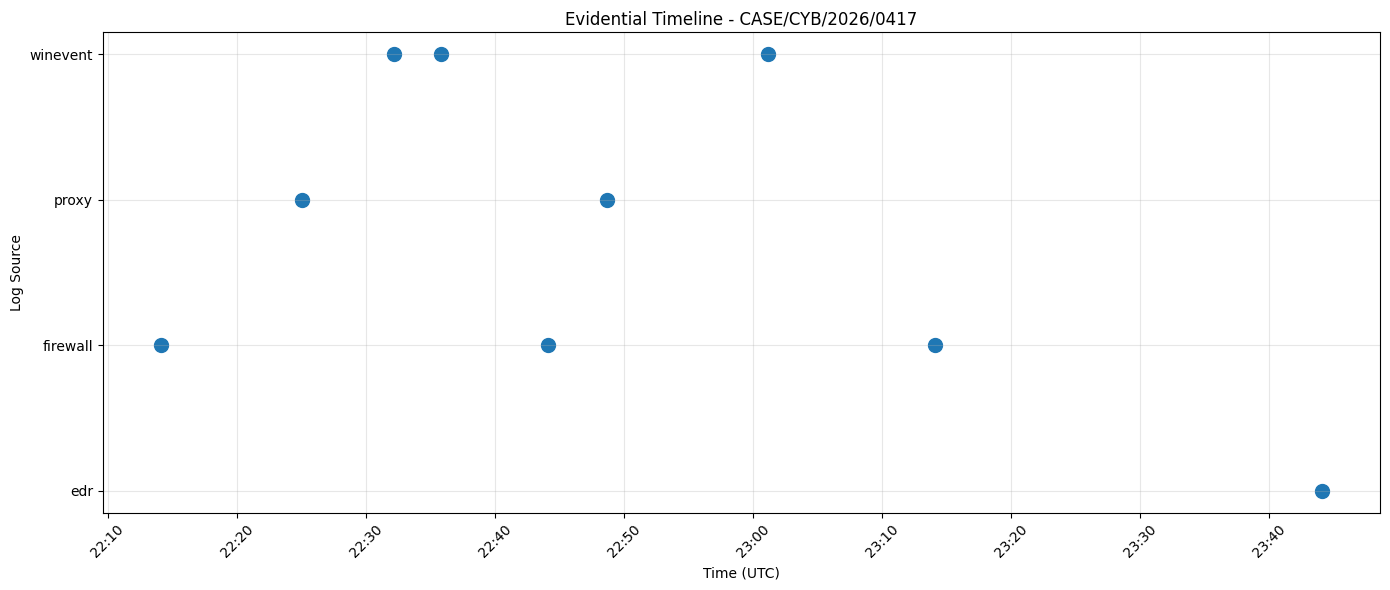


TEST CASE RESULTS
TC1 every log line parsed                               -> PASS
TC2 timeline sorted ascending                           -> PASS
TC3 all timestamps converted to UTC                     -> PASS
TC4 IST 04:02:11 -> UTC 22:32:11 previous day           -> PASS
TC5 upload precedes audit-log clearing                  -> PASS
TC6 unknown timestamp rejected                          -> PASS
TC7 30-minute beaconing detected                        -> PASS
TC8 timeline image generated                            -> PASS
TC9 timeline contains all events                        -> PASS

RESULT: 9/9 test cases passed

FINAL RESULT
Experiment 9 completed successfully.
Timeline normalized to UTC and IST.
Beaconing pattern analyzed successfully.
Generated file: timeline.png


In [1]:
# ============================================================
# EXPERIMENT 9
# RECONSTRUCTING AN EVIDENTIAL TIMELINE FROM HETEROGENEOUS LOGS
# ============================================================

import re
import os
from datetime import datetime, timezone, timedelta

# ------------------------------------------------------------
# TIME ZONES
# ------------------------------------------------------------

IST = timezone(timedelta(hours=5, minutes=30))
UTC = timezone.utc


# ------------------------------------------------------------
# SAMPLE FORENSIC LOGS
# ------------------------------------------------------------

RAW_LOGS = [

    ("firewall",
     "2026-08-19T22:14:07Z ALLOW 10.20.3.41 -> 203.0.113.90:443 bytes=1204"),

    ("firewall",
     "2026-08-19T22:44:07Z ALLOW 10.20.3.41 -> 203.0.113.90:443 bytes=1198"),

    ("firewall",
     "2026-08-19T23:14:07Z ALLOW 10.20.3.41 -> 203.0.113.90:443 bytes=1211"),

    ("winevent",
     "20/08/2026 04:02:11 +0530 EventID=4624 LogonType=3 Account=svc_backup Host=FS01"),

    ("winevent",
     "20/08/2026 04:05:52 +0530 EventID=4720 NewAccount=svc_helper Host=DC01"),

    ("winevent",
     "20/08/2026 04:31:09 +0530 EventID=1102 AuditLogCleared Host=FS01"),

    ("proxy",
     "Aug 20 2026 04:18:44 IST user=svc_backup url=https://files.example.net/upload size=41231872"),

    ("proxy",
     "Aug 20 2026 03:55:02 IST user=r.kumar url=https://intranet/hr size=8123"),

    ("edr",
     "2026-08-19T23:44:07Z proc=powershell.exe parent=winword.exe host=WS0142 cmd=EncodedCommand")
]


# ------------------------------------------------------------
# TIMESTAMP PATTERNS
# ------------------------------------------------------------

PATTERNS = [

    (
        re.compile(r"^(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}Z)"),
        lambda s: datetime.strptime(
            s, "%Y-%m-%dT%H:%M:%SZ"
        ).replace(tzinfo=UTC)
    ),

    (
        re.compile(
            r"^(\d{2}/\d{2}/\d{4} \d{2}:\d{2}:\d{2} \+0530)"
        ),
        lambda s: datetime.strptime(
            s, "%d/%m/%Y %H:%M:%S %z"
        )
    ),

    (
        re.compile(
            r"^([A-Z][a-z]{2} \d{2} \d{4} \d{2}:\d{2}:\d{2}) IST"
        ),
        lambda s: datetime.strptime(
            s, "%b %d %Y %H:%M:%S"
        ).replace(tzinfo=IST)
    )
]


# ------------------------------------------------------------
# TIMESTAMP ERROR
# ------------------------------------------------------------

class TimestampError(ValueError):
    pass


# ------------------------------------------------------------
# PARSE TIMESTAMP
# ------------------------------------------------------------

def parse_timestamp(line):

    for pattern, function in PATTERNS:

        match = pattern.match(line)

        if match:
            return function(
                match.group(1)
            ).astimezone(UTC)

    raise TimestampError(
        f"Unrecognised timestamp: {line[:50]!r}"
    )


# ------------------------------------------------------------
# BUILD FORENSIC TIMELINE
# ------------------------------------------------------------

def build_timeline(raw=RAW_LOGS):

    events = []

    for source, line in raw:

        ts = parse_timestamp(line)

        events.append({
            "utc": ts,
            "ist": ts.astimezone(IST),
            "source": source,
            "detail": line
        })

    # Sort events chronologically using UTC
    events.sort(key=lambda e: e["utc"])

    return events


# ------------------------------------------------------------
# BEACONING DETECTION
# ------------------------------------------------------------

def detect_beaconing(
    events,
    source="firewall",
    tolerance_s=60
):

    firewall_times = [
        e["utc"]
        for e in events
        if e["source"] == source
    ]

    if len(firewall_times) < 3:
        return False, []

    gaps = [

        (
            firewall_times[i]
            - firewall_times[i - 1]
        ).total_seconds()

        for i in range(1, len(firewall_times))
    ]

    regular = (
        max(gaps) - min(gaps)
        <= tolerance_s
    )

    return regular, gaps


# ------------------------------------------------------------
# PRINT TIMELINE TABLE
# ------------------------------------------------------------

def render(events):

    print("\n" + "=" * 120)
    print("FORENSIC EVIDENTIAL TIMELINE")
    print("=" * 120)

    print(
        f"{'#':<4}"
        f"{'UTC':<26}"
        f"{'IST':<26}"
        f"{'SOURCE':<12}"
        f"EVENT"
    )

    print("-" * 120)

    for i, event in enumerate(events, 1):

        utc_time = event["utc"].strftime(
            "%Y-%m-%d %H:%M:%S UTC"
        )

        ist_time = event["ist"].strftime(
            "%Y-%m-%d %H:%M:%S IST"
        )

        print(
            f"{i:<4}"
            f"{utc_time:<26}"
            f"{ist_time:<26}"
            f"{event['source']:<12}"
            f"{event['detail'][:55]}"
        )


# ------------------------------------------------------------
# CREATE TIMELINE CHART
# ------------------------------------------------------------

def plot_timeline(
    events,
    path="timeline.png"
):

    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    sources = sorted(
        set(e["source"] for e in events)
    )

    ymap = {
        source: i
        for i, source in enumerate(sources)
    }

    plt.figure(figsize=(14, 6))

    x = [
        e["utc"]
        for e in events
    ]

    y = [
        ymap[e["source"]]
        for e in events
    ]

    plt.scatter(
        x,
        y,
        s=100
    )

    plt.yticks(
        range(len(sources)),
        sources
    )

    plt.xlabel(
        "Time (UTC)"
    )

    plt.ylabel(
        "Log Source"
    )

    plt.title(
        "Evidential Timeline - CASE/CYB/2026/0417"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.gca().xaxis.set_major_formatter(
        mdates.DateFormatter(
            "%H:%M"
        )
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        path,
        dpi=150
    )

    plt.show()

    return path


# ============================================================
# TEST CASES
# ============================================================

def run_tests():

    events = build_timeline()

    results = []

    # TC1
    results.append(
        (
            "TC1 every log line parsed",
            len(events) == len(RAW_LOGS)
        )
    )

    # TC2
    results.append(
        (
            "TC2 timeline sorted ascending",
            all(
                events[i]["utc"]
                >= events[i - 1]["utc"]
                for i in range(1, len(events))
            )
        )
    )

    # TC3
    results.append(
        (
            "TC3 all timestamps converted to UTC",
            all(
                e["utc"].tzinfo == UTC
                for e in events
            )
        )
    )

    # TC4
    windows_event = [
        e for e in events
        if "4624" in e["detail"]
    ][0]

    expected_time = datetime(
        2026,
        8,
        19,
        22,
        32,
        11,
        tzinfo=UTC
    )

    results.append(
        (
            "TC4 IST 04:02:11 -> UTC 22:32:11 previous day",
            windows_event["utc"] == expected_time
        )
    )

    # TC5
    upload = [
        e for e in events
        if "upload" in e["detail"]
    ][0]

    clearing = [
        e for e in events
        if "1102" in e["detail"]
    ][0]

    upload_index = events.index(upload)
    clearing_index = events.index(clearing)

    results.append(
        (
            "TC5 upload precedes audit-log clearing",
            upload_index < clearing_index
        )
    )

    # TC6
    try:

        parse_timestamp(
            "invalid timestamp"
        )

        raised = False

    except TimestampError:

        raised = True

    results.append(
        (
            "TC6 unknown timestamp rejected",
            raised
        )
    )

    # TC7
    regular, gaps = detect_beaconing(
        events
    )

    results.append(
        (
            "TC7 30-minute beaconing detected",
            regular
            and all(
                abs(g - 1800) < 1
                for g in gaps
            )
        )
    )

    # TC8
    image_path = plot_timeline(
        events
    )

    results.append(
        (
            "TC8 timeline image generated",
            os.path.exists(image_path)
            and os.path.getsize(image_path) > 1000
        )
    )

    # TC9
    table_lines = len(
        render_for_test(events).split("\n")
    )

    results.append(
        (
            "TC9 timeline contains all events",
            table_lines == len(events) + 2
        )
    )

    # Print results
    print("\n" + "=" * 70)
    print("TEST CASE RESULTS")
    print("=" * 70)

    for name, passed in results:

        print(
            f"{name:<55} -> "
            f"{'PASS' if passed else 'FAIL'}"
        )

    passed_count = sum(
        1 for _, ok in results if ok
    )

    print(
        f"\nRESULT: {passed_count}/{len(results)} "
        "test cases passed"
    )

    return passed_count == len(results)


# ------------------------------------------------------------
# TEST RENDER FUNCTION
# ------------------------------------------------------------

def render_for_test(events):

    lines = [
        "UTC | IST | SOURCE | EVENT",
        "-" * 100
    ]

    for e in events:

        lines.append(
            f"{e['utc']} | "
            f"{e['ist']} | "
            f"{e['source']} | "
            f"{e['detail']}"
        )

    return "\n".join(lines)


# ============================================================
# MAIN EXECUTION
# ============================================================

print("\n")
print("=" * 70)
print("EXPERIMENT 9")
print("RECONSTRUCTING AN EVIDENTIAL TIMELINE")
print("=" * 70)

# Build timeline
events = build_timeline()

# Display timeline
render(events)

# Beacon detection
regular, gaps = detect_beaconing(events)

print("\n" + "=" * 70)
print("BEACONING ANALYSIS")
print("=" * 70)

print(
    "Beaconing detected:",
    regular
)

print(
    "Connection intervals:",
    [int(g) for g in gaps],
    "seconds"
)

if regular:

    print(
        "Pattern:",
        "Regular automated activity detected "
        "(approximately 30-minute interval)."
    )

# Run all tests
run_tests()

print("\n" + "=" * 70)
print("FINAL RESULT")
print("=" * 70)

print(
    "Experiment 9 completed successfully."
)

print(
    "Timeline normalized to UTC and IST."
)

print(
    "Beaconing pattern analyzed successfully."
)

print(
    "Generated file: timeline.png"
)